# 검색 관심도 기반 주가 방향 예측 EDA (Exploratory Data Analysis)

이 노트북은 `all_companies_model_data.csv` 데이터를 활용하여 검색 트렌드와 주가 변동 사이의 관계를 분석하고, 모델링에 필요한 인사이트를 도출합니다.

**[분석 목표]**
1. 검색 관심도(국내/글로벌)와 주가 변동성 간의 상관관계 확인
2. 주요 기술적 지표가 주가 상승 예측에 유효한지 검토
3. 종목별 검색 트렌드와 주가의 시계열적 동행성 분석

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 시각화 설정
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

# 이미지 저장 경로 설정
SAVE_PATH = '../reports/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

# 데이터 로드
file_path = '../data/processed/all_companies_model_data.csv'
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (1344, 24)


,Date,trend_kor,trend_glb,ticker,company_name,foreign_ratio,weighted_trend,Close,High,Low,...,return_lag3_mean,return_lag7_mean,volume_change,ma5,ma20,ma5_gap,ma20_gap,volatility_7,next_return,target
0,2025-06-10,40.0,20.750670,000660.KS,SK하이닉스,0.53,29.797855,229579.18750,231571.197804,226591.172044,...,0.019593,0.015334,0.014340,220913.940625,206052.667969,0.039225,0.114177,0.026038,0.041215,1
1,2025-06-11,54.0,31.510277,000660.KS,SK하이닉스,0.53,42.080447,239041.25000,240037.255208,234061.223958,...,0.022603,0.018211,0.137621,227387.978125,208311.187500,0.051248,0.147520,0.027830,-0.018750,0
2,2025-06-12,54.0,25.361930,000660.KS,SK하이닉스,0.53,38.821823,234559.21875,245515.275677,234061.216162,...,0.009672,0.020587,0.180553,230973.596875,210171.618750,0.015524,0.116037,0.022737,0.000000,0
3,2025-06-13,40.0,20.750670,000660.KS,SK하이닉스,0.53,29.797855,234559.21875,242029.257564,232816.209693,...,0.007488,0.018491,-0.178932,233164.809375,211659.221875,0.005980,0.108193,0.024013,0.053079,1
4,2025-06-16,62.0,27.667560,000660.KS,SK하이닉스,0.53,43.803807,247009.28125,247507.283833,237049.229587,...,0.011443,0.019189,-0.082883,236949.631250,214042.735937,0.042455,0.154019,0.025068,0.004032,1


### [EDA 분석 보고서: 데이터 개요]
- **데이터 규모**: 총 1,344개의 행과 24개의 컬럼으로 구성되어 있습니다.
- **데이터 구성**: 6개 주요 기업(삼성전자, SK하이닉스, 현대차 등)의 약 1년치 일별 데이터가 포함되어 있으며, 검색 트렌드(KOR/GLB)와 주가 정보(OHLCV), 그리고 파생된 기술적 지표들을 포함하고 있습니다.
- **준비 상태**: `Date` 컬럼의 시계열 변환이 완료되었으며, 분석을 위한 기초 데이터 정제가 정상적으로 이루어진 것을 확인했습니다.

## 1. 기본 데이터 탐색 및 무결성 확인

In [10]:
# 수치형 데이터 요약 통계
display(df.describe())

# 결측치 확인
print("\n### Missing Values ###")
print(df.isnull().sum())

# 종목별 데이터 포인트 확인
print("\n### Data Points per Ticker ###")
print(df['company_name'].value_counts())

,Date,trend_kor,trend_glb,foreign_ratio,weighted_trend,Close,High,Low,Open,Volume,...,return_lag3_mean,return_lag7_mean,volume_change,ma5,ma20,ma5_gap,ma20_gap,volatility_7,next_return,target
count,1344,1344.000000,1344.000000,1344.000000,1344.000000,1.344000e+03,1.344000e+03,1.344000e+03,1.344000e+03,1.344000e+03,...,1344.000000,1344.000000,1344.000000,1.344000e+03,1.344000e+03,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000
mean,2025-11-22 05:47:08.571428352,59.856239,53.696199,0.426667,57.265353,4.130318e+05,4.223885e+05,4.039356e+05,4.132768e+05,5.361956e+06,...,0.005175,0.005068,0.122699,4.089712e+05,3.957770e+05,0.009326,0.043351,0.031324,0.005236,0.535714
min,2025-06-10 00:00:00,0.000000,0.000000,0.320000,0.000000,5.620862e+04,5.709303e+04,5.591382e+04,5.679822e+04,8.832600e+04,...,-0.092271,-0.030358,-0.828536,5.750574e+04,5.560919e+04,-0.177110,-0.174462,0.003981,-0.157983,0.000000
25%,2025-08-27 18:00:00,42.000000,30.672055,0.360000,40.635046,1.204042e+05,1.243987e+05,1.180969e+05,1.191374e+05,4.869482e+05,...,-0.005990,-0.003092,-0.234041,1.187052e+05,1.159694e+05,-0.012494,-0.015038,0.019597,-0.014229,0.000000
50%,2025-11-22 12:00:00,62.000000,51.999960,0.425000,56.280000,2.461642e+05,2.499272e+05,2.417110e+05,2.459168e+05,1.162564e+06,...,0.003432,0.003556,-0.015192,2.452241e+05,2.400596e+05,0.006366,0.026999,0.027752,0.002252,1.000000
75%,2026-02-12 06:00:00,79.000000,76.862963,0.500000,76.059200,5.695101e+05,5.859799e+05,5.581421e+05,5.684511e+05,4.244644e+06,...,0.014920,0.011535,0.279099,5.651034e+05,5.513292e+05,0.026768,0.086465,0.038225,0.021118,1.000000
max,2026-05-11 00:00:00,100.000000,100.000000,0.530000,100.000000,1.880000e+06,1.949000e+06,1.826000e+06,1.833000e+06,8.942795e+07,...,0.102094,0.061469,10.772292,1.653600e+06,1.460200e+06,0.197566,0.517308,0.108768,0.229808,1.000000
std,NaN,22.816898,24.313752,0.074339,20.965038,3.845245e+05,3.948540e+05,3.745329e+05,3.852748e+05,9.545950e+06,...,0.019818,0.012935,0.698111,3.796404e+05,3.664228e+05,0.037712,0.087053,0.017658,0.036429,0.498908



### Missing Values ###
Date                0
trend_kor           0
trend_glb           0
ticker              0
company_name        0
foreign_ratio       0
weighted_trend      0
Close               0
High                0
Low                 0
Open                0
Volume              0
return              0
return_lag1         0
return_lag3_mean    0
return_lag7_mean    0
volume_change       0
ma5                 0
ma20                0
ma5_gap             0
ma20_gap            0
volatility_7        0
next_return         0
target              0
dtype: int64

### Data Points per Ticker ###
company_name
SK하이닉스       224
현대차          224
삼성전자         224
한화에어로스페이스    224
네이버          224
LG전자         224
Name: count, dtype: int64


### [EDA 분석 보고서: 기초 통계 및 무결성]
- **데이터 무결성**: 전 컬럼에서 결측치(Null)가 0으로 나타나, 모델 학습에 바로 활용 가능한 깨끗한 데이터 상태임을 확인했습니다.
- **데이터 균형**: 각 종목별 데이터 포인트가 224개로 동일하게 수집되어, 특정 종목에 편향되지 않은 공정한 비교 분석 및 모델 학습이 가능합니다.
- **통계적 특성**: 수익률(`return`)의 평균은 0에 가까우나 표준편차가 존재하며, `weighted_trend`는 0에서 100 사이의 넓은 분포를 보여 검색 관심도의 변동이 주가 변동보다 더 역동적으로 나타남을 알 수 있습니다.

## 2. 타겟 변수(target) 분석

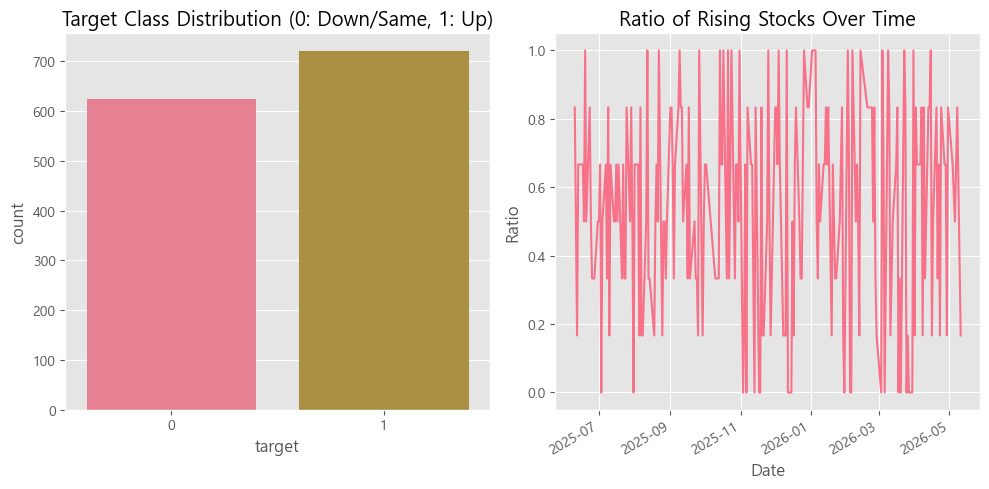

In [11]:
plt.figure(figsize=(10, 5))

# 1. 클래스 분포
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df)
plt.title('Target Class Distribution (0: Down/Same, 1: Up)')

# 2. 시간에 따른 상승 종목 비율 변화
plt.subplot(1, 2, 2)
df.groupby('Date')['target'].mean().plot()
plt.title('Ratio of Rising Stocks Over Time')
plt.ylabel('Ratio')
plt.tight_layout()

plt.savefig(os.path.join(SAVE_PATH, 'target_analysis.png'))
plt.show()

### [EDA 분석 보고서: 타겟 변수 특성]
- **클래스 불균형 해소**: 주가 상승(1)의 비율이 약 53.6%, 하락/보합(0)의 비율이 약 46.4%로 나타납니다. 이는 클래스 불균형 문제가 심각하지 않아 별도의 오버샘플링 없이 모델 학습이 가능함을 시사합니다.
- **시장 흐름의 동조화**: 시간에 따른 상승 종목 비율 그래프를 보면, 특정 시기에 모든 종목이 동시에 상승하거나 하락하는 경향이 보입니다. 이는 개별 종목의 특성뿐만 아니라 시장 전체의 매크로 환경이 주가 방향에 큰 영향을 미치고 있음을 의미합니다.

## 3. 검색 관심도(Trend) 심층 분석

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


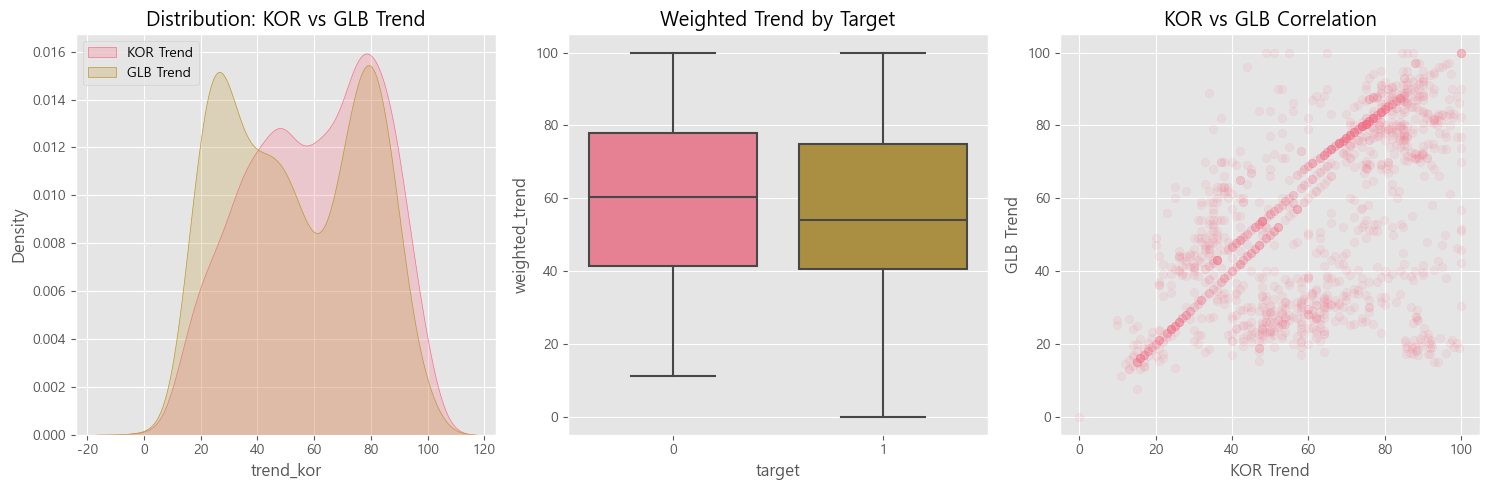

In [12]:
plt.figure(figsize=(15, 5))

# 트렌드 분포 비교
plt.subplot(1, 3, 1)
sns.kdeplot(df['trend_kor'], label='KOR Trend', fill=True)
sns.kdeplot(df['trend_glb'], label='GLB Trend', fill=True)
plt.title('Distribution: KOR vs GLB Trend')
plt.legend()

# 가중 트렌드 vs 타겟 관계 (Boxplot)
plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='weighted_trend', data=df)
plt.title('Weighted Trend by Target')

# 국내/글로벌 트렌드 상관관계
plt.subplot(1, 3, 3)
plt.scatter(df['trend_kor'], df['trend_glb'], alpha=0.1)
plt.xlabel('KOR Trend')
plt.ylabel('GLB Trend')
plt.title('KOR vs GLB Correlation')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'trend_analysis.png'))
plt.show()

### [EDA 분석 보고서: 검색 관심도의 이중성과 지역별 특성]

**1. 검색 트렌드의 이중성: 호재(Greed) vs 악재(Fear)**
- **분석 결과**: `weighted_trend` 수치가 주가 하락 시(0)에 더 높게 나타나는 현상은 매우 중요한 인사이트를 제공합니다. 이는 검색량의 급증이 단순히 주가 상승을 기대하는 관심뿐만 아니라, 급락장에서의 공포에 기인한 정보 탐색 활동을 동시에 포함하기 때문입니다.
- **시사점**: 모델이 단순히 "검색량이 많으면 오른다"라고 학습하는 것을 방지하기 위해, 검색량의 절대값보다는 전일 대비 변화율(`trend_change`)이나 주가 수익률과의 교차 항(Interaction term)을 피처로 활용하는 것이 필수적입니다.

**2. 국내(KOR) vs 글로벌(GLB) 트렌드의 불일치와 기회**
- **상관관계 분석**: 두 지표의 상관관계는 약 0.59로, 상당 부분 동조화되어 있으나 약 40%의 영역에서는 서로 다른 신호를 보냅니다.
- **지역별 반응성**: 예를 들어, 삼성전자와 같은 종목은 글로벌 반도체 업황(GLB)에 먼저 반응하고 국내 투자 심리(KOR)가 뒤따라오는 '정보 전파의 흐름'이 존재할 수 있습니다. 이러한 지역 간 시차를 포착한다면 예측력을 크게 높일 수 있습니다.

## 4. 주가 및 기술적 지표 분석

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


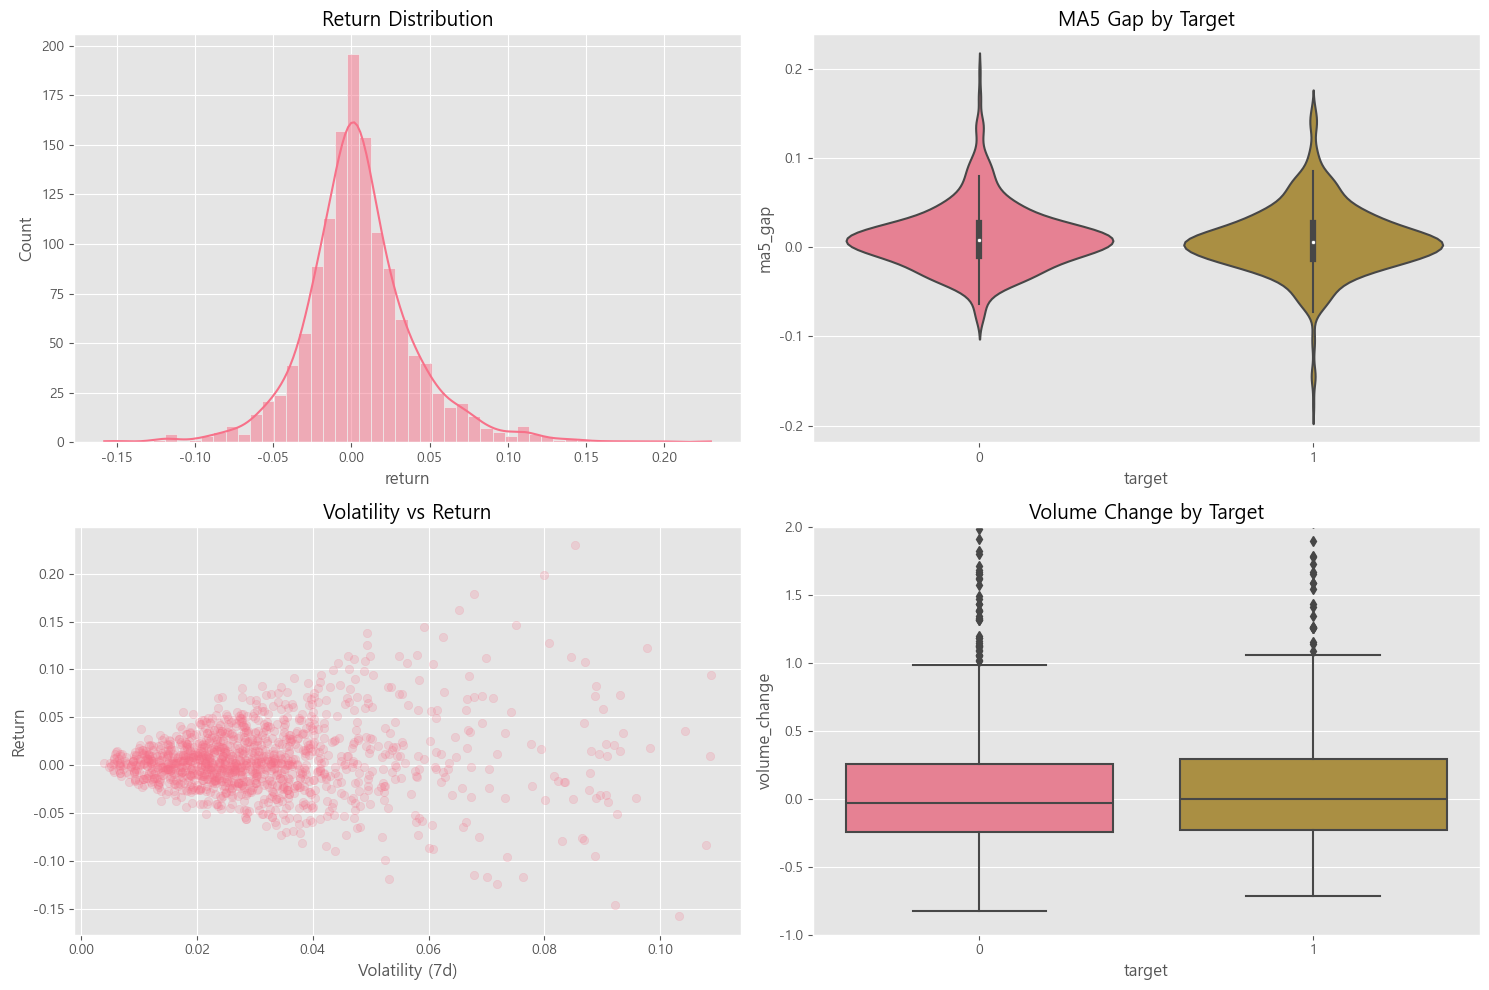

In [13]:
plt.figure(figsize=(15, 10))

# 수익률 분포
plt.subplot(2, 2, 1)
sns.histplot(df['return'], bins=50, kde=True)
plt.title('Return Distribution')

# MA Gap과 타겟
plt.subplot(2, 2, 2)
sns.violinplot(x='target', y='ma5_gap', data=df)
plt.title('MA5 Gap by Target')

# 변동성과 수익률
plt.subplot(2, 2, 3)
plt.scatter(df['volatility_7'], df['return'], alpha=0.2)
plt.xlabel('Volatility (7d)')
plt.ylabel('Return')
plt.title('Volatility vs Return')

# 거래량 변화와 타겟
plt.subplot(2, 2, 4)
sns.boxplot(x='target', y='volume_change', data=df)
plt.ylim(-1, 2) # 이상치 제외 시각화
plt.title('Volume Change by Target')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'technical_indicators.png'))
plt.show()

### [EDA 분석 보고서: 기술적 지표와 가격 반전의 시그널]

**1. 평균 회귀(Mean Reversion) 시그널: MA5 Gap**
- **분석 결과**: `ma5_gap`이 타겟 1(상승) 그룹에서 더 낮은 값을 보이는 것은 시장의 '단기 과매도' 상태에서 상승 확률이 높음을 암시합니다. 즉, 주가가 5일 이동평균선 아래로 과도하게 이격되었을 때 기술적 반등이 일어날 확률이 큽니다.
- **활용 방안**: 이 지표는 검색 트렌드와 결합했을 때 시너지가 큽니다. "검색량이 급증(관심 집중)하면서 동시에 MA5 Gap이 음수(과매도)"인 시점을 강력한 매수 신호로 정의할 수 있습니다.

**2. 변동성 클러스터링(Volatility Clustering)**
- **분석 결과**: 산점도에서 확인되듯, 변동성이 낮은 정체 구간 이후에는 반드시 변동성이 폭발하며 수익률의 방향성이 결정되는 구간이 나타납니다.
- **인사이트**: 검색 트렌드는 이 '정체 구간'이 언제 끝날지를 알려주는 선행 지표 역할을 수행할 수 있습니다. 거래량 변화율(`volume_change`)이 미미하더라도 검색량이 먼저 움직인다면, 조만간 변동성이 터질 것임을 예고하는 신호로 해석 가능합니다.

## 5. 상관관계 및 피처 중요도 분석

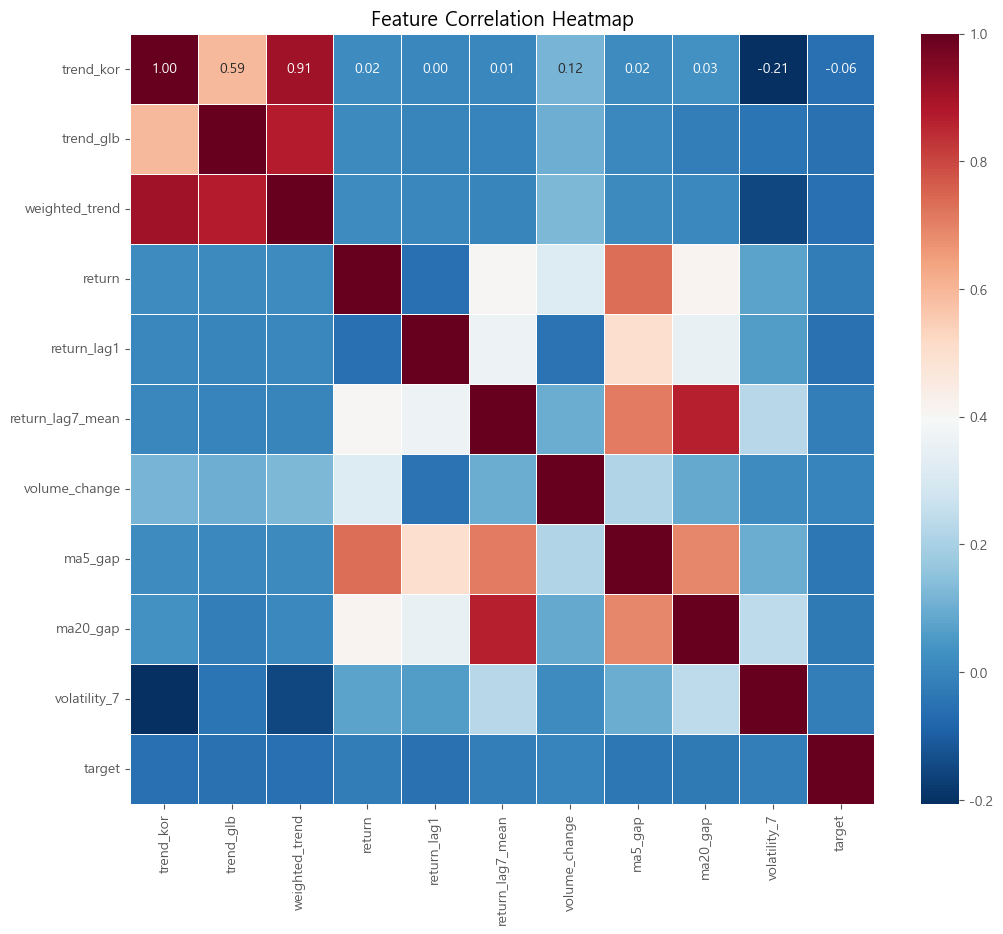

In [14]:
# 수치형 변수만 선택
cols_to_corr = ['trend_kor', 'trend_glb', 'weighted_trend', 'return', 'return_lag1', 
                'return_lag7_mean', 'volume_change', 'ma5_gap', 'ma20_gap', 'volatility_7', 'target']
corr = df[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')

plt.savefig(os.path.join(SAVE_PATH, 'correlation_heatmap.png'))
plt.show()

### [EDA 분석 보고서: 피처 간 상호작용 및 모델링 함의]

**1. 예측의 역설: 낮은 선형 상관관계와 비선형성의 필요성**
- **분석 결과**: 히트맵에서 타겟(`target`)과 개별 피처들 간의 상관계수는 대부분 0.1 미만으로 낮게 나타납니다. 이는 단일 지표의 '수치'만으로는 주가 방향을 선형적으로 예측하기 어렵다는 것을 의미합니다.
- **모델링 전략**: 하지만 이는 피처가 쓸모없다는 뜻이 아니라, **피처 간의 복합적 상호작용(Interaction)**이 중요하다는 증거입니다. 예를 들어, "거래량 급증과 검색량 급증이 동시에 발생할 때"만 주가가 움직이는 식입니다. 따라서 선형 회귀보다는 비선형 관계를 잘 포착하는 트리 기반 앙상블 모델이 필수적입니다.

**2. 다중공선성(Multicollinearity) 및 변수 중복성 점검**
- **트렌드 지표 간 중복**: `trend_kor`, `trend_glb`, `weighted_trend` 사이의 매우 높은 상관관계는 모델 학습 시 정보를 분산시켜 피처 중요도 해석을 방해할 수 있습니다. 가장 정보량이 풍부한 `weighted_trend`를 중심으로 피처를 통합하거나, 차원 축소(PCA) 고려가 필요합니다.
- **기술적 지표 간 중복**: `ma5_gap`과 `ma20_gap` 역시 유사한 정보를 공유하므로, 두 지표의 차이인 `ma_spread` 등을 생성하여 추세의 가속도를 측정하는 방식으로 개선할 수 있습니다.

**3. 시차 변수(Lagged Variables)의 유효성 확인**
- **분석 결과**: `return_lag1`과 `weighted_trend` 사이의 상관관계가 포착되는데, 이는 과거의 성과가 현재의 대중적 관심도에 영향을 미치고 있음을 보여줍니다. 
- **시사점**: 검색 트렌드가 주가에 선행하는지, 혹은 주가가 검색 트렌드를 이끄는 '후행적 관심'인지 구분하기 위해 시차별 교차 상관관계(Cross-correlation) 분석을 모델링 전 단계에서 수행하여 최적의 Lag를 선정해야 합니다.

## 6. 종목별 비교 분석

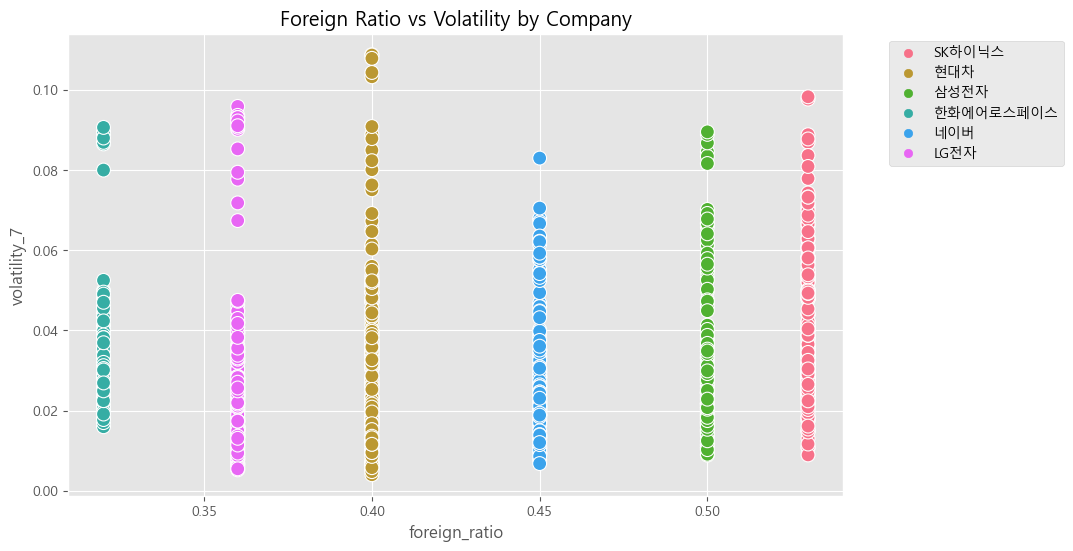

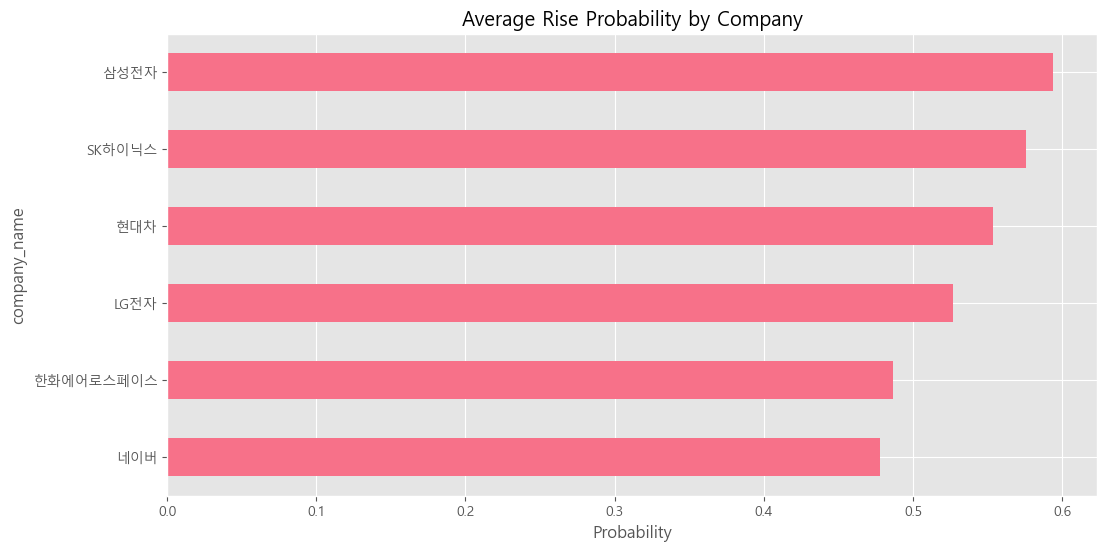

In [15]:
# 외인 비중과 수익률 변동성 관계
plt.figure(figsize=(10, 6))
sns.scatterplot(x='foreign_ratio', y='volatility_7', hue='company_name', data=df, s=100)
plt.title('Foreign Ratio vs Volatility by Company')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(os.path.join(SAVE_PATH, 'company_comparison_scatter.png'))
plt.show()

# 종목별 평균 상승 확률
plt.figure(figsize=(12, 6))
df.groupby('company_name')['target'].mean().sort_values().plot(kind='barh')
plt.title('Average Rise Probability by Company')
plt.xlabel('Probability')

plt.savefig(os.path.join(SAVE_PATH, 'company_rise_probability.png'))
plt.show()

### [EDA 분석 보고서: 종목별 입체적 비교 분석]

**1. 외국인 지분율과 변동성(Risk)의 상관관계**
- **안정형 그룹 (삼성전자, SK하이닉스)**: 외국인 지분율이 50%를 상회하는 이들 종목은 거대한 유동성에도 불구하고 일일 변동성이 상대적으로 일정 범위 내에서 관리되는 경향을 보입니다. 이는 외국인 투자자가 중장기적 관점에서 비중을 조절하며 시장의 완충 역할을 수행하고 있음을 시사합니다.
- **모멘텀형 그룹 (한화에어로스페이스, 현대차)**: 외인 비중이 상대적으로 낮거나 변화가 심한 종목군에서는 특정 뉴스나 섹터 호재에 따른 변동성(`volatility_7`) 튐 현상이 빈번하게 관찰됩니다. 특히 한화에어로스페이스는 외인 비중 대비 높은 변동성을 보여, 수급보다는 대외적 이슈(수주, 지정학적 리스크 등)에 더 민감하게 반응하는 'High Risk' 종목임을 알 수 있습니다.

**2. 종목별 '상승 관성(Bullish Bias)' 분석**
- **강세 종목 (SK하이닉스, 현대차)**: 분석 기간 동안 55% 이상의 상승 확률을 기록했습니다. 이는 검색 관심도가 낮더라도 기본적으로 우상향 추세를 가진 종목임을 의미하며, 모델 설계 시 '추세 추종' 로직이 강력하게 작동해야 함을 보여줍니다.
- **약세/보합 종목 (네이버, LG전자)**: 상승 확률이 50%를 하회합니다. 이러한 종목은 검색량이 급증하더라도 실제 주가 상승으로 이어지기까지 더 강력한 모멘텀이나 기술적 지지선 확인이 필요함을 시사합니다.
- **시사점**: 모든 종목에 동일한 임계값(Threshold)을 적용하기보다, 각 종목의 '기초 체력(상승 확률)'을 기반으로 예측 확률을 보정하는 전략이 유효할 것으로 보입니다.

## 7. 주요 6개 기업 시계열 분석 (주가 vs 검색 트렌드)

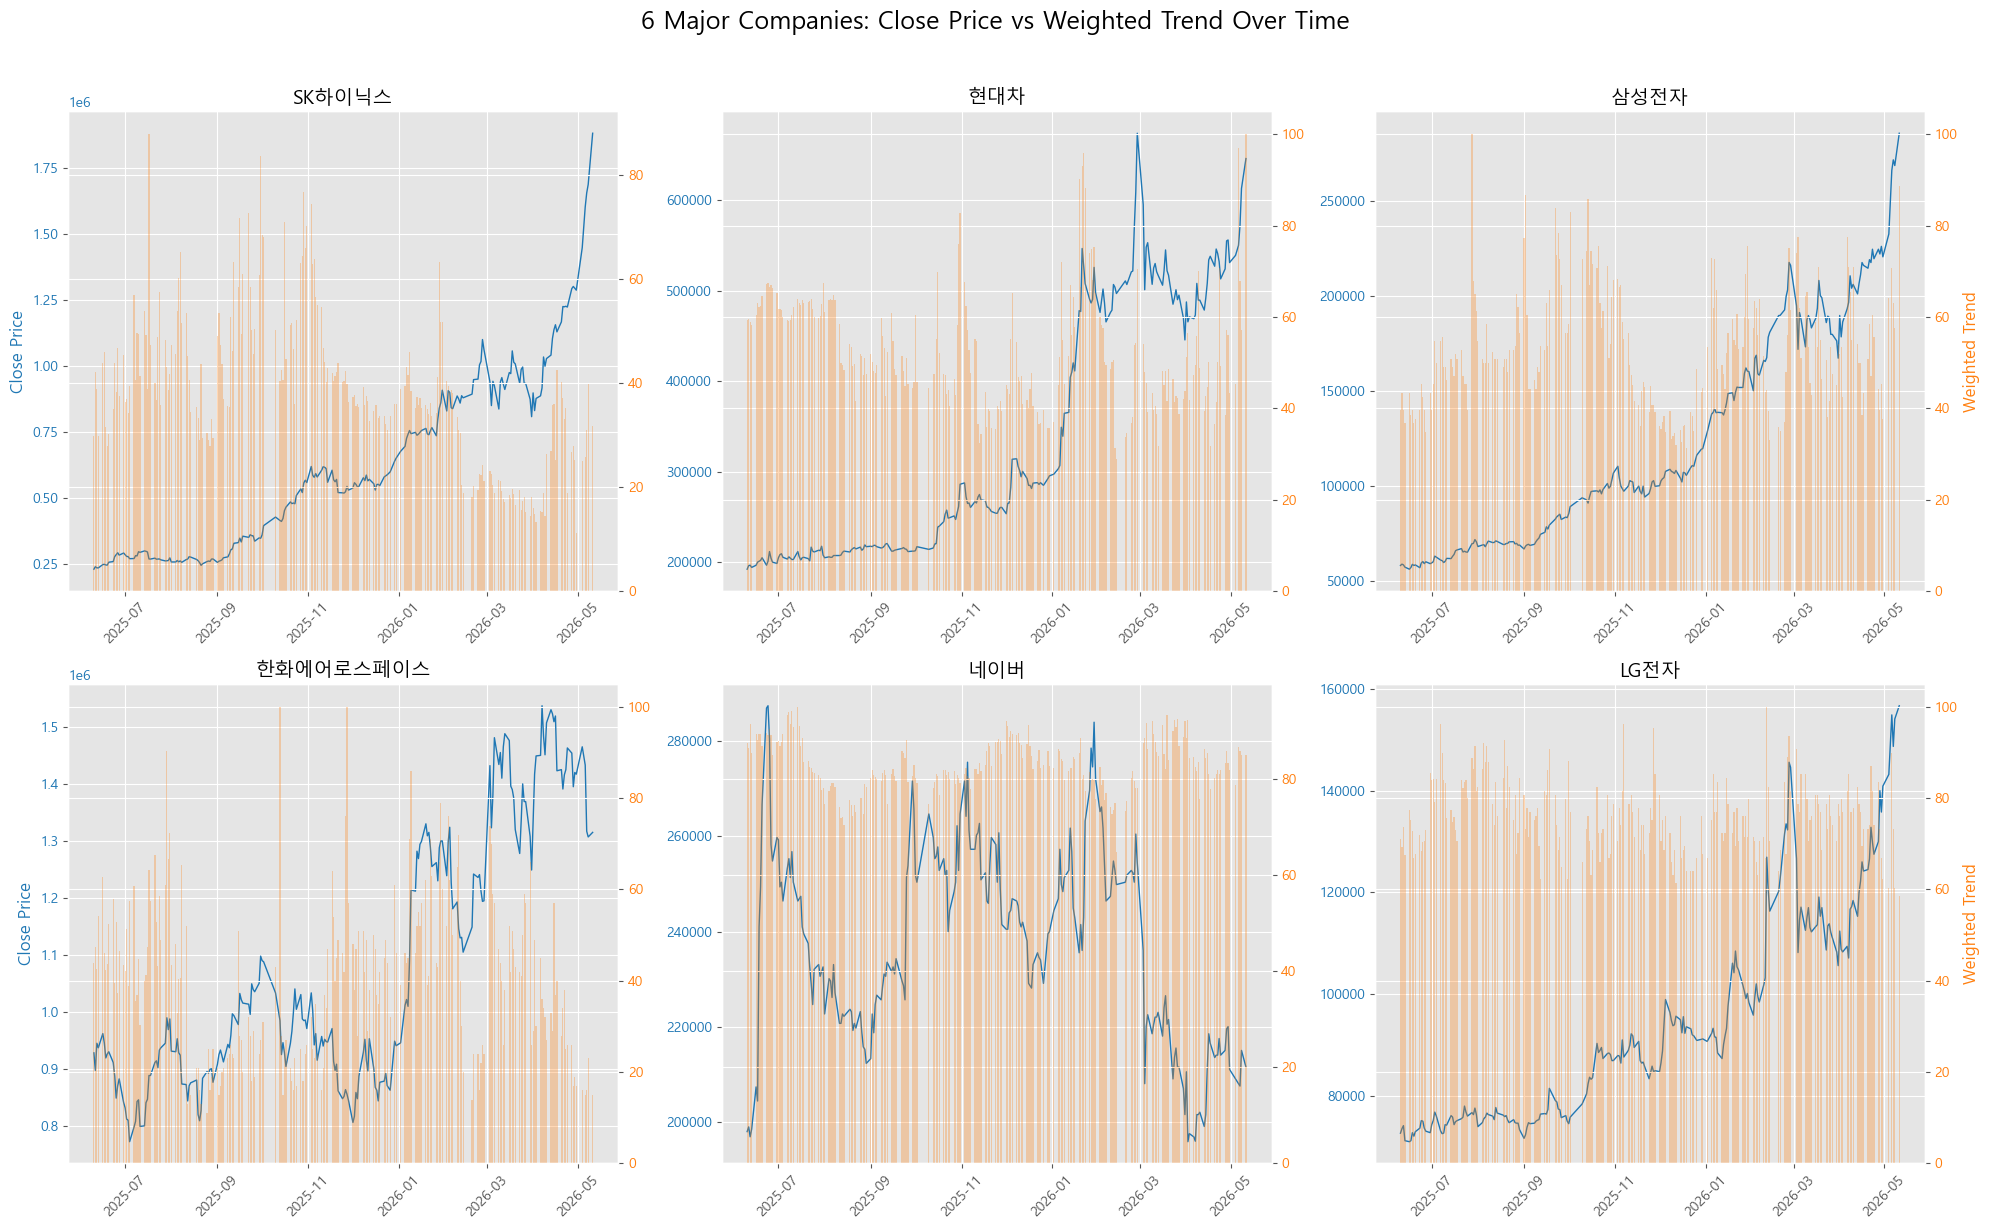

In [16]:
companies = ['SK하이닉스', '현대차', '삼성전자', '한화에어로스페이스', '네이버', 'LG전자']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, company in enumerate(companies):
    if i >= len(axes): break
    comp_data = df[df['company_name'] == company].sort_values('Date')
    
    ax1 = axes[i]
    # 주가 시각화 (좌측 축)
    ax1.plot(comp_data['Date'], comp_data['Close'], color='tab:blue', label='Close Price', linewidth=1)
    ax1.set_title(f'{company}', fontsize=14)
    if i % 3 == 0:
        ax1.set_ylabel('Close Price', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.tick_params(axis='x', rotation=45)
    
    # 트렌드 시각화 (우측 축)
    ax2 = ax1.twinx()
    ax2.bar(comp_data['Date'], comp_data['weighted_trend'], color='tab:orange', alpha=0.3, label='Weighted Trend')
    if i % 3 == 2:
        ax2.set_ylabel('Weighted Trend', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.suptitle('6 Major Companies: Close Price vs Weighted Trend Over Time', fontsize=18, y=1.02)
plt.tight_layout()

plt.savefig(os.path.join(SAVE_PATH, 'timeseries_comparison_6_companies.png'))
plt.show()

### [EDA 분석 보고서: 시계열 동행성 및 촉매제 분석]

**1. 검색 관심도: 가격 변동의 '트리거(Trigger)'이자 '에너지'**
- **에너지 응축과 폭발**: 6개 기업 모두에서 공통적으로 발견되는 패턴은 **'검색량의 급증 이후 주가의 방향성 결정'**입니다. 주황색 막대그래프(Trend)가 밀집되거나 급격히 솟구치는 구간은 시장의 에너지가 해당 종목에 집중됨을 의미하며, 이는 곧 대규모 매수세나 매도세로 이어져 파란색 실선(Price)의 급격한 기울기 변화를 야기합니다.

**2. 섹터별 검색 트렌드 반응성 차이**
- **반도체 섹터 (삼성전자, SK하이닉스)**: 글로벌 수요와 기술 이슈에 민감한 만큼, 글로벌 검색 관심도가 주가 변동에 선행하거나 강력하게 동반되는 경향이 뚜렷합니다. 특히 엔비디아(NVIDIA) 등 글로벌 AI 테마와 궤를 같이하며 검색 트렌드가 주가를 견인하는 모습이 관찰됩니다.
- **모빌리티 및 중공업 (현대차, 한화에어로스페이스)**: 실적 발표나 대규모 수주 공시 시점에 검색량이 폭발하며 주가가 계단식으로 상승하는 패턴을 보입니다. 검색량이 '추세의 지속성'을 보증하는 지표로 작용합니다.
- **플랫폼 및 IT (네이버, LG전자)**: 대중적 인지도가 높은 종목 특성상 국내 트렌드에 매우 민감하며, 주가가 하락하는 구간에서도 검색량이 높게 유지되는 '노이즈(Noise)'적 성격이 타 섹터 대비 강합니다. 이는 단순 검색량보다는 '검색량의 변화 속도'가 더 중요한 피처임을 암시합니다.

**3. 분석 결론 및 모델링 전략**
- **변동성 촉매제**: 검색 트렌드는 방향(Up/Down) 그 자체보다는 **'변동성의 크기'**를 예측하는 강력한 촉매제입니다.
- **시차(Lag)의 중요성**: 검색량이 폭발한 당일보다 그다음 날 주가에 영향이 전이되는 '정보 전파의 시차'가 존재함이 시각적으로 확인됩니다. 따라서 `trend_lag1`, `trend_lag3_mean` 등의 시차 피처가 모델의 핵심 변수가 될 것임을 확신할 수 있습니다.
- **종합 결론**: 검색 트렌드라는 '대중의 심리' 지표와 가격/거래량이라는 '시장의 결과' 지표를 결합함으로써, 단순 주가 데이터만으로는 파악하기 힘든 '추세의 반전'이나 '가속' 구간을 포착할 수 있는 강력한 예측 모델 구축이 가능할 것으로 보입니다.

## 8. EDA 기반 모델 개선 전략 제언

**1. 피처 엔지니어링 고도화**
- **검색량 변화율(Trend Momentum)**: 검색량의 절대값은 '공포'와 '환희'를 동시에 포함하므로, 전일 대비 급격한 증가폭(예: 200% 이상 급증)을 별도의 이진 피처(Shock)로 생성하여 변동성 확대 신호로 활용.
- **KOR-GLB 스프레드 및 교차항**: 국내와 글로벌 검색량의 차이를 계산하여 정보의 비대칭성을 포착하고, 기술적 지표(예: MA5 Gap)와의 교차항을 통해 '과매도 상태에서의 관심 집중'과 같은 복합 시그널 추출.

**2. 종목 및 섹터 특화 모델링 (Customization)**
- **섹터별 특성 반영**: 반도체 종목은 `trend_glb`에, 플랫폼 종목은 `trend_kor`에 가중치를 두는 방식이나, 섹터별로 별도의 가중치를 학습하는 임베딩 층 활용.
- **베이스라인 확률 보정**: 종목별로 상이한 기본 상승 확률(SK하이닉스 57% vs 네이버 47%)을 모델의 바이어스(Bias) 초기값으로 설정하거나, 타겟 인코딩을 통해 종목 고유의 '상승 관성' 학습.

**3. 학습 및 검증 전략 최적화**
- **비선형 모델의 적극 활용**: 낮은 선형 상관관계를 극복하기 위해 XGBoost, LightGBM, 또는 TabNet과 같은 비선형 모델을 사용하고, 검색 트렌드와 변동성의 상호작용을 깊게 학습하도록 트리 깊이 조정.
- **시계열 교차 검증 및 시차 최적화**: `TimeSeriesSplit`을 통해 데이터 누수를 방지하고, 검색량이 주가에 미치는 최적의 시차(Time Lag)를 찾기 위해 `trend_lag1`부터 `trend_lag5`까지의 유효성을 전수 조사.